# Lab 01 – Introductory Computer Vision Lab
Sheikh Naveed Azeemi
23K-0003

In [1]:
# 1.1 Installation
%pip install opencv-python matplotlib

OpenCV version    : 4.14.0
Matplotlib version: 3.10.0


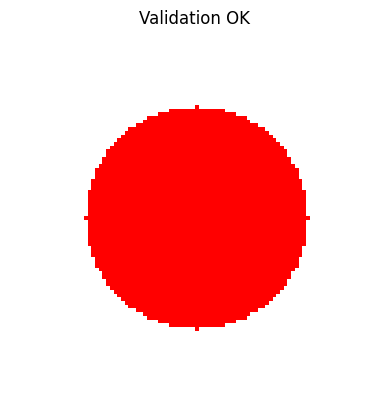

In [2]:
# 1.2 Import & Validate
import cv2
import matplotlib.pyplot as plt

print('OpenCV version    :', cv2.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# quick functional test: draw on a tiny image and show it
test = cv2.circle(255 * __import__('numpy').ones((100, 100, 3), dtype='uint8'), (50, 50), 30, (255, 0, 0), -1)
plt.imshow(test); plt.axis('off'); plt.title('Validation OK'); plt.show()

### Setup: shared imports, image paths & helper (run once)

In [4]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# ---- Change these to your own file names ----
IMAGE_PATH   = 'Sample document·jpg'     # main image
IMAGE_PATH_2 = 'image2.jpg'      # second image (used in Task 8)
DOC_PATH     = 'document.jpg'    # grayscale document / high-contrast image (Task 7)

def load_rgb(path, fallback='astronaut'):
    # Loads an image as RGB; uses a scikit-image sample if the file is missing.
    img = cv2.imread(path)
    if img is None:
        print(f"Error: Image not found at '{path}'. Using sample image '{fallback}' instead.")
        from skimage import data
        return getattr(data, fallback)()
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
# OPTIONAL: upload your images from your computer (skip if you already uploaded them)
# from google.colab import files
# uploaded = files.upload()

## Part 2: Python Data Structures & Logic

### Task 1: Object-Oriented Grocery Manager

In [5]:
class GroceryManager:
    def __init__(self):
        self.items = {}   # {item: {'quantity': int, 'price': float}}

    def add_item(self, item, quantity, price):
        if quantity <= 0 or price < 0:
            print('Error: quantity must be > 0 and price must be >= 0.')
            return
        if item in self.items:
            self.items[item]['quantity'] += quantity
            self.items[item]['price'] = price
        else:
            self.items[item] = {'quantity': quantity, 'price': price}
        print(f"Added {quantity} x {item} @ {price}")

    def remove_item(self, item):
        if item not in self.items:
            print(f"Error: '{item}' does not exist in the list.")
            return
        del self.items[item]
        print(f"Removed '{item}'.")

    def view_list(self):
        if not self.items:
            print('The grocery list is empty.')
            return
        print(f"{'Item':<15}{'Qty':>5}{'Price':>10}{'Subtotal':>12}")
        print('-' * 42)
        for name, d in self.items.items():
            print(f"{name:<15}{d['quantity']:>5}{d['price']:>10.2f}{d['quantity'] * d['price']:>12.2f}")

    def calculate_total(self):
        return sum(d['quantity'] * d['price'] for d in self.items.values())


# ---- Demo ----
gm = GroceryManager()
gm.add_item('Milk', 2, 150.0)
gm.add_item('Bread', 1, 100.0)
gm.add_item('Eggs', 12, 25.0)
gm.view_list()
print('Total:', gm.calculate_total())
gm.remove_item('Bread')
gm.remove_item('Butter')   # doesn't exist -> error message
gm.view_list()
print('Total:', gm.calculate_total())

Added 2 x Milk @ 150.0
Added 1 x Bread @ 100.0
Added 12 x Eggs @ 25.0
Item             Qty     Price    Subtotal
------------------------------------------
Milk               2    150.00      300.00
Bread              1    100.00      100.00
Eggs              12     25.00      300.00
Total: 700.0
Removed 'Bread'.
Error: 'Butter' does not exist in the list.
Item             Qty     Price    Subtotal
------------------------------------------
Milk               2    150.00      300.00
Eggs              12     25.00      300.00
Total: 600.0


### Task 2: Advanced Student Record System

In [6]:
students = {
    101: {'Name': 'Ali',    'Major': 'Computer Science', 'Grades': [85, 90, 78]},
    102: {'Name': 'Sara',   'Major': 'Data Science',     'Grades': [92, 88, 95]},
    103: {'Name': 'Ahmed',  'Major': 'Computer Science', 'Grades': [70, 65, 80]},
    104: {'Name': 'Fatima', 'Major': 'Electrical Eng.',  'Grades': [88, 84, 91]},
}

def top_student(records):
    best_name, best_avg = None, -1
    for sid, info in records.items():
        if not info['Grades']:
            continue
        avg = sum(info['Grades']) / len(info['Grades'])
        if avg > best_avg:
            best_name, best_avg = info['Name'], avg
    return best_name

def search_by_major(records, major):
    found = [info['Name'] for info in records.values() if info['Major'].lower() == major.lower()]
    if found:
        print(f"Students in '{major}':")
        for name in found:
            print('  -', name)
    else:
        print(f"No students found in '{major}'.")

print('Highest average grade:', top_student(students))
search_by_major(students, 'Computer Science')
search_by_major(students, 'Physics')

Highest average grade: Sara
Students in 'Computer Science':
  - Ali
  - Ahmed
No students found in 'Physics'.


## Part 3: Core Computer Vision & Matplotlib
### Task 3: Safe Image Loading & RGB Visualization

In [7]:
image_path = IMAGE_PATH
image = cv2.imread(image_path)

if image is None:
    print('Error: Image not found.')
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.show()

Error: Image not found.


### Task 4: Interactive Geometry & Blank Canvas

Canvas size   : 800 x 800
Canvas center : (400, 400)


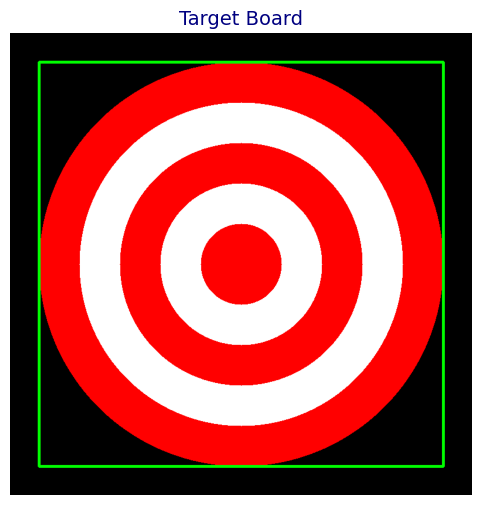

In [8]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)   # 800x800 black image
h, w = canvas.shape[:2]
center = (w // 2, h // 2)

# 5 concentric circles (outermost first), alternating red / white
radii  = [350, 280, 210, 140, 70]
colors = [(255, 0, 0), (255, 255, 255), (255, 0, 0), (255, 255, 255), (255, 0, 0)]   # RGB
for r, c in zip(radii, colors):
    cv2.circle(canvas, center, r, c, -1)

# bounding box around the outermost circle
R = radii[0]
cv2.rectangle(canvas, (center[0] - R, center[1] - R), (center[0] + R, center[1] + R), (0, 255, 0), 3)

print(f'Canvas size   : {w} x {h}')
print(f'Canvas center : {center}')

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.axis('off')
plt.title('Target Board', fontsize=14, color='navy')
plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction

Error: Image not found at 'Sample document·jpg'. Using sample image 'astronaut' instead.


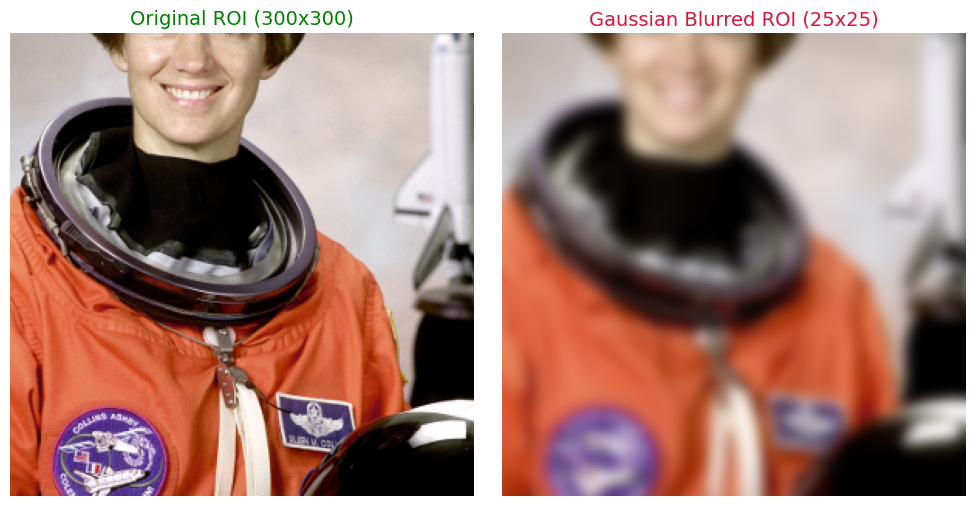

In [9]:
img = load_rgb(IMAGE_PATH, fallback='astronaut')
blurred = cv2.GaussianBlur(img, (25, 25), 0)

h, w = img.shape[:2]
assert h >= 300 and w >= 300, 'Image must be at least 300x300 for this task.'
cy, cx = h // 2, w // 2
y1, y2 = cy - 150, cy + 150
x1, x2 = cx - 150, cx + 150

roi_original = img[y1:y2, x1:x2]
roi_blurred  = blurred[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(roi_original); axes[0].axis('off')
axes[0].set_title('Original ROI (300x300)', fontsize=14, color='green')
axes[1].imshow(roi_blurred);  axes[1].axis('off')
axes[1].set_title('Gaussian Blurred ROI (25x25)', fontsize=14, color='crimson')
plt.tight_layout()
plt.show()

### Task 6: Alpha Blending & Typography

Error: Image not found at 'Sample document·jpg'. Using sample image 'astronaut' instead.


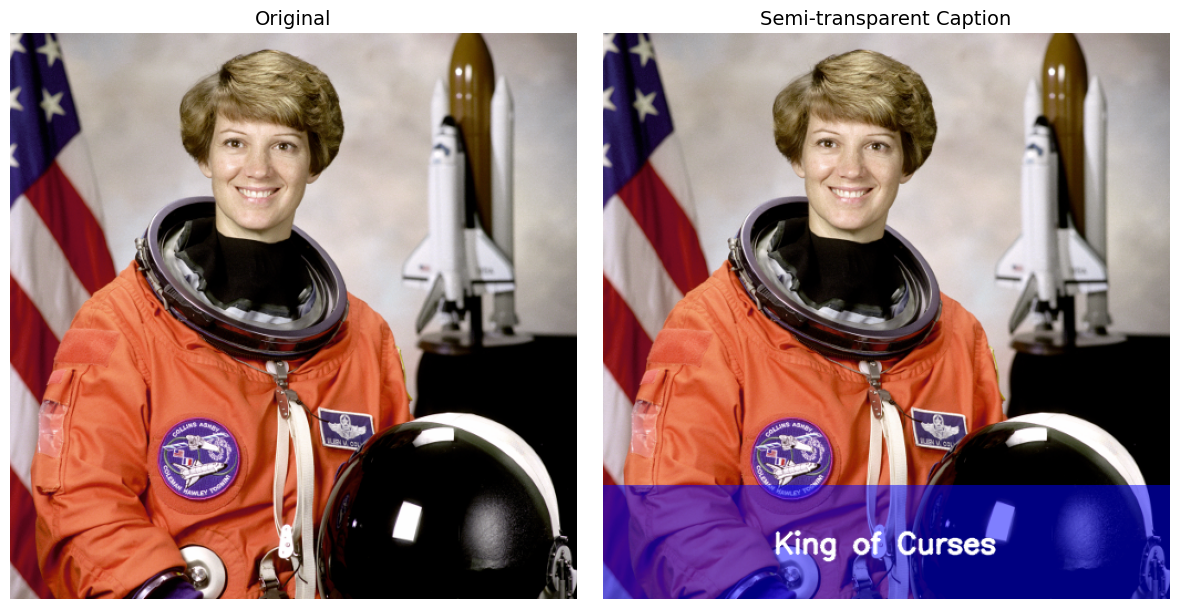

In [10]:
img = load_rgb(IMAGE_PATH, fallback='astronaut')
h, w = img.shape[:2]

overlay = img.copy()
y_start = int(h * 0.80)                                   # bottom 20%
cv2.rectangle(overlay, (0, y_start), (w, h), (0, 0, 255), -1)   # blue (RGB)

alpha = 0.5
blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

text = 'King of Curses'
font = cv2.FONT_HERSHEY_SIMPLEX
scale = w / 600
thickness = max(2, int(w / 300))
(tw, th), _ = cv2.getTextSize(text, font, scale, thickness)
pos = ((w - tw) // 2, y_start + (h - y_start + th) // 2)
cv2.putText(blended, text, pos, font, scale, (255, 255, 255), thickness, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img);     axes[0].axis('off'); axes[0].set_title('Original', fontsize=14)
axes[1].imshow(blended); axes[1].axis('off'); axes[1].set_title('Semi-transparent Caption', fontsize=14)
plt.tight_layout()
plt.show()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

Error: Image not found at 'document.jpg'. Using sample document instead.


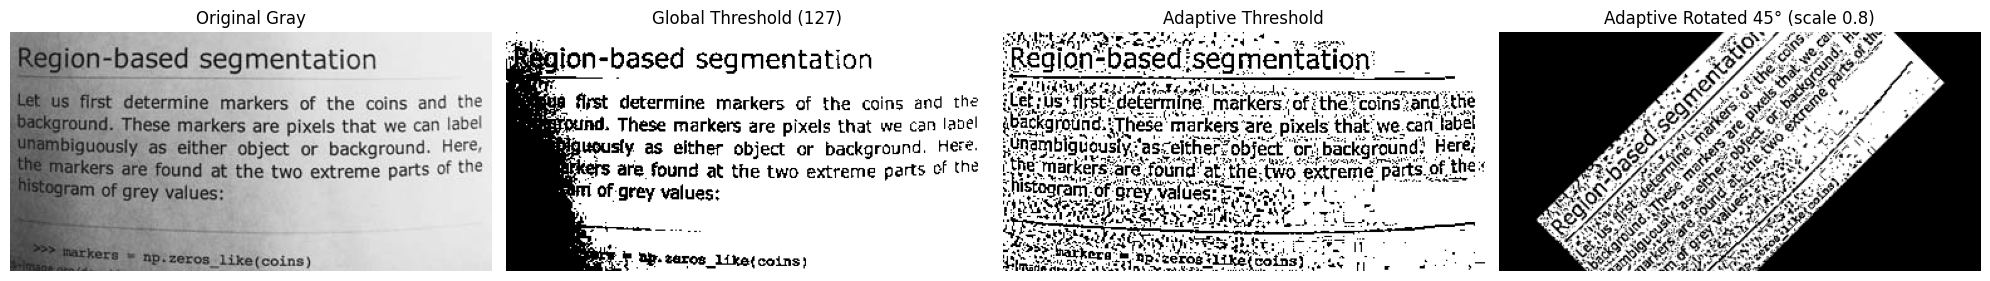

In [11]:
gray = cv2.imread(DOC_PATH, cv2.IMREAD_GRAYSCALE)
if gray is None:
    print(f"Error: Image not found at '{DOC_PATH}'. Using sample document instead.")
    from skimage import data
    gray = data.page()

# Global binary threshold
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive threshold (handles uneven lighting)
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 11, 2)

# Rotate adaptive output by 45 degrees, scale 0.8
h, w = adaptive.shape
M = cv2.getRotationMatrix2D((w // 2, h // 2), 45, 0.8)
rotated = cv2.warpAffine(adaptive, M, (w, h))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original Gray', 'Global Threshold (127)', 'Adaptive Threshold', 'Adaptive Rotated 45° (scale 0.8)']
for ax, im, t in zip(axes, [gray, global_thresh, adaptive, rotated], titles):
    ax.imshow(im, cmap='gray'); ax.axis('off'); ax.set_title(t, fontsize=12)
plt.tight_layout()
plt.show()

### Task 8: Masking with Bitwise Logic

Error: Image not found at 'Sample document·jpg'. Using sample image 'astronaut' instead.
Error: Image not found at 'image2.jpg'. Using sample image 'coffee' instead.


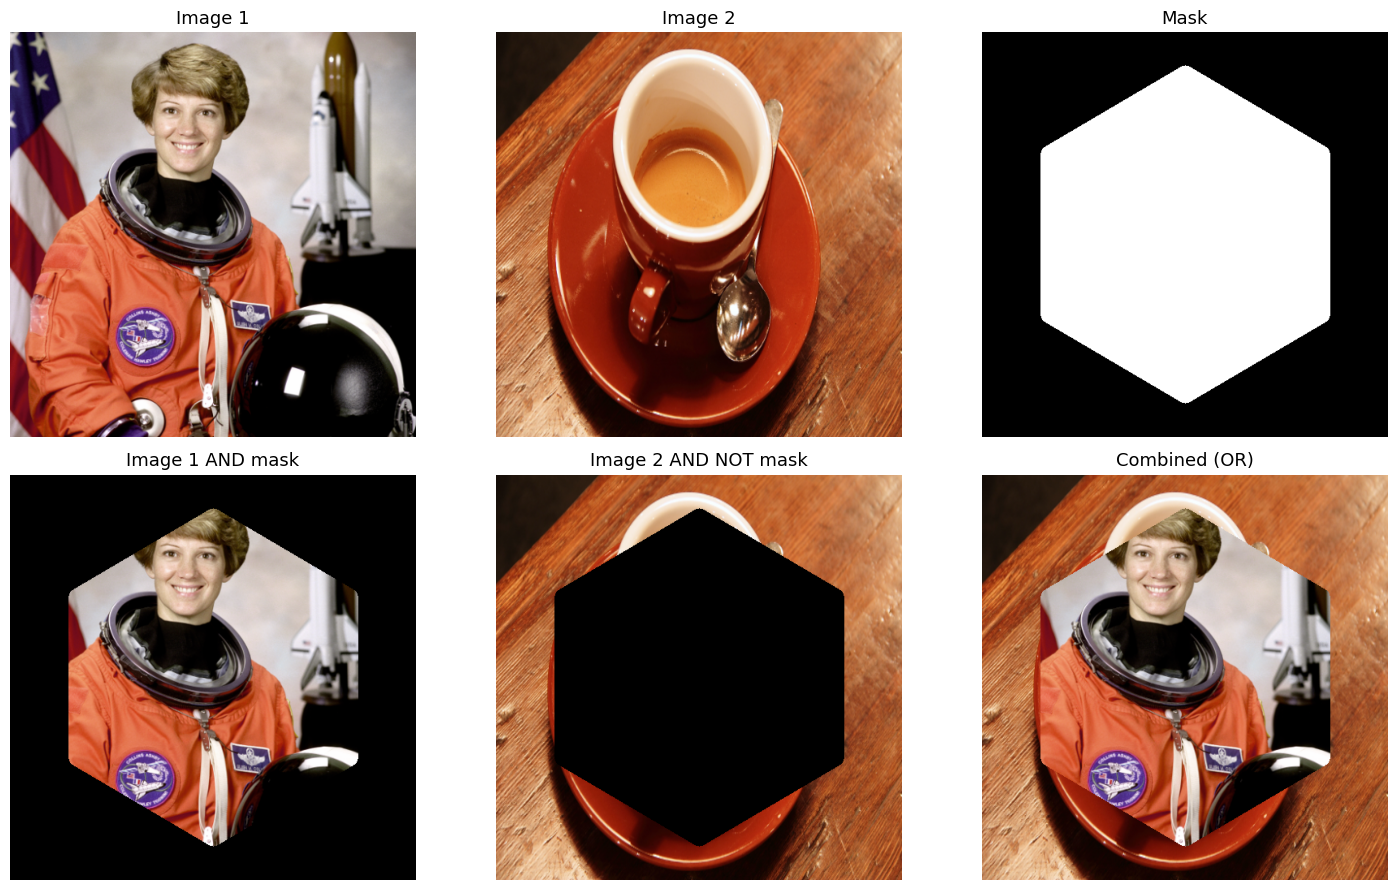

In [12]:
img1 = cv2.resize(load_rgb(IMAGE_PATH,   fallback='astronaut'), (500, 500))
img2 = cv2.resize(load_rgb(IMAGE_PATH_2, fallback='coffee'),    (500, 500))

# Binary mask: black background with a thick white filled polygon (hexagon) in the center
mask = np.zeros((500, 500), dtype=np.uint8)
pts = np.array([[250, 50], [420, 150], [420, 350], [250, 450], [80, 350], [80, 150]], np.int32)
cv2.fillPoly(mask, [pts], 255)
cv2.polylines(mask, [pts], True, 255, 15)   # thicken the edge

# Image 1 inside the polygon
fg = cv2.bitwise_and(img1, img1, mask=mask)

# Image 2 outside the polygon (inverted mask)
mask_inv = cv2.bitwise_not(mask)
bg = cv2.bitwise_and(img2, img2, mask=mask_inv)

# Combine
combined = cv2.bitwise_or(fg, bg)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
items = [(img1, 'Image 1'), (img2, 'Image 2'), (mask, 'Mask'),
         (fg, 'Image 1 AND mask'), (bg, 'Image 2 AND NOT mask'), (combined, 'Combined (OR)')]
for ax, (im, t) in zip(axes.ravel(), items):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off'); ax.set_title(t, fontsize=13)
plt.tight_layout()
plt.show()

### Task 9: Statistical Image Profiling with Pandas

In [13]:
img = load_rgb(IMAGE_PATH, fallback='astronaut')   # RGB order

df = pd.DataFrame({
    'Red':   img[:, :, 0].flatten(),
    'Green': img[:, :, 1].flatten(),
    'Blue':  img[:, :, 2].flatten(),
})

print(f'Image shape: {img.shape}  |  DataFrame shape: {df.shape}\n')
print(df.describe())

Error: Image not found at 'Sample document·jpg'. Using sample image 'astronaut' instead.
Image shape: (512, 512, 3)  |  DataFrame shape: (262144, 3)

                 Red          Green           Blue
count  262144.000000  262144.000000  262144.000000
mean      141.562492     105.759445      96.475075
std        82.039098      76.615607      77.853578
min         0.000000       0.000000       0.000000
25%        74.000000      24.000000      19.000000
50%       175.000000     107.000000      82.000000
75%       210.000000     178.000000     172.000000
max       255.000000     255.000000     255.000000
